C:\Users\Dipankar Bagade\AppData\Local\Temp\ipykernel_20748\1768191003.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_genres.index, x=top_genres.values, palette="viridis")


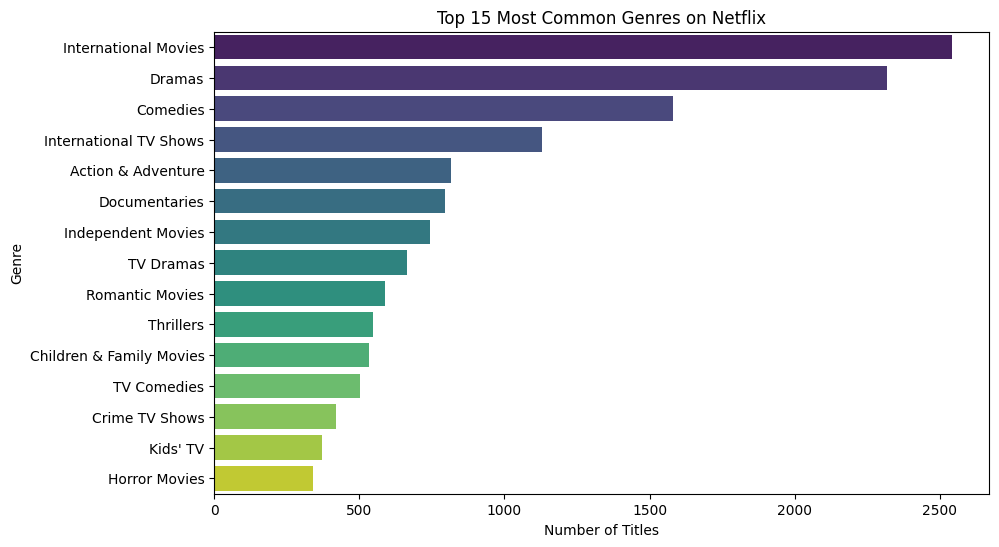

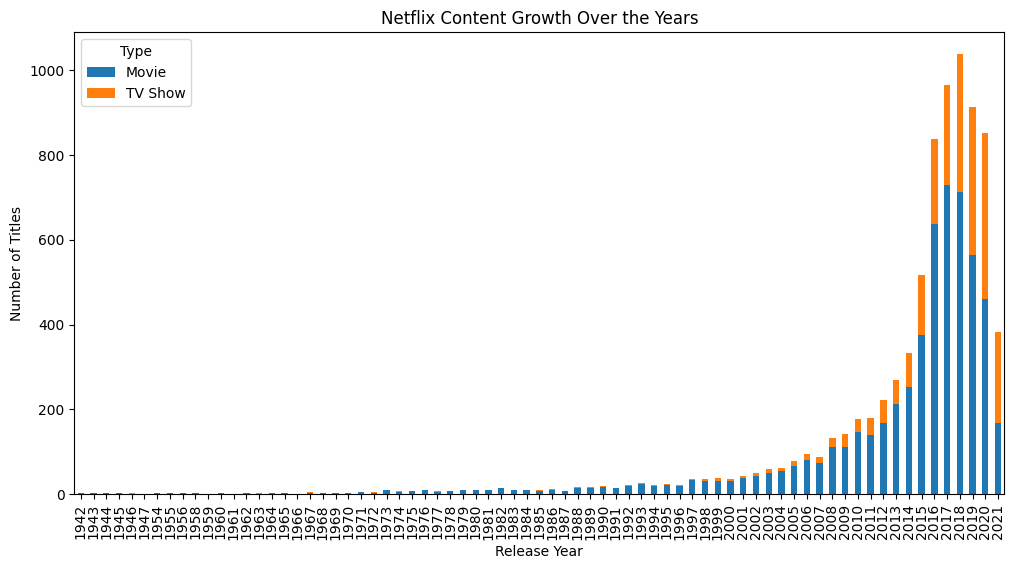

C:\Users\Dipankar Bagade\AppData\Local\Temp\ipykernel_20748\1768191003.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="crest")


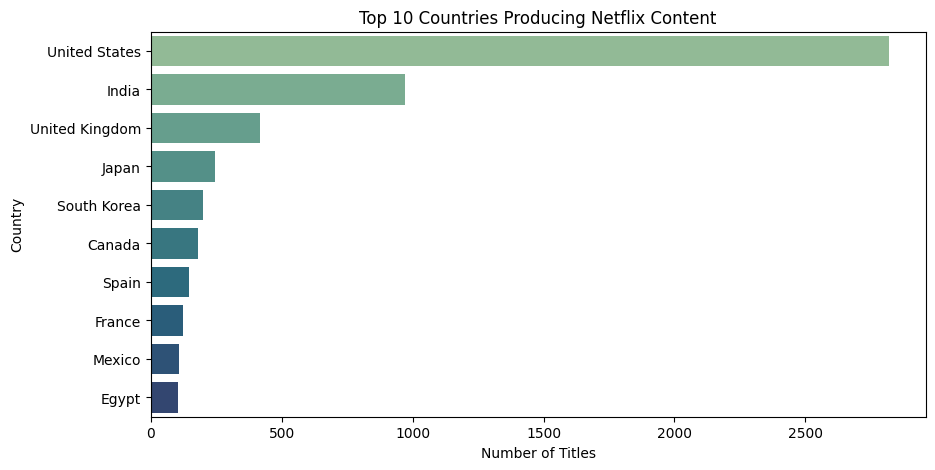

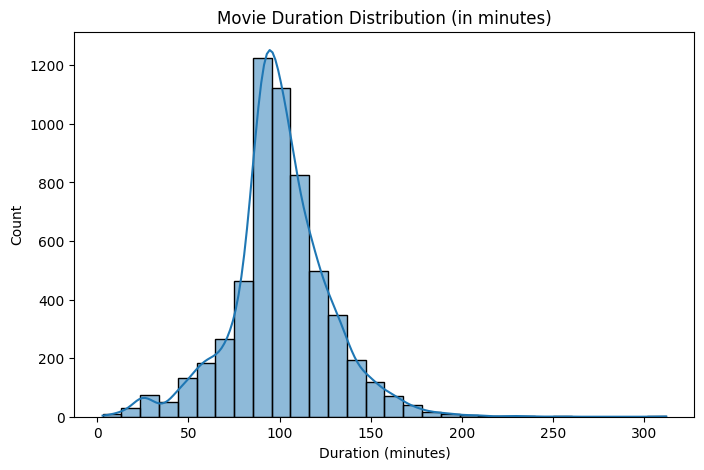

C:\Users\Dipankar Bagade\AppData\Local\Temp\ipykernel_20748\1768191003.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette="magma")


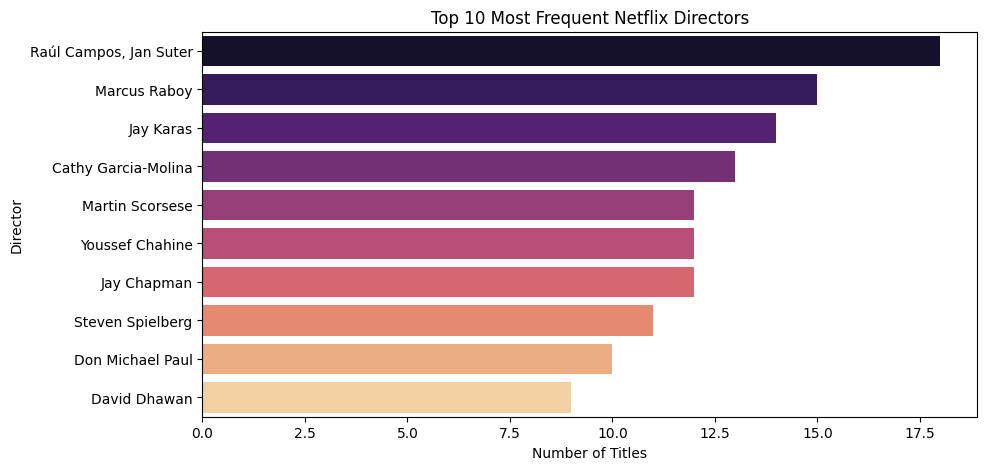

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/netflix_titles.csv")
df.drop_duplicates(inplace=True)
df.dropna(subset=['type','country','release_year','listed_in'], inplace=True)

genre_split = df['listed_in'].str.split(',').explode().str.strip()

top_genres = genre_split.value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(y=top_genres.index, x=top_genres.values, palette="viridis")
plt.title("Top 15 Most Common Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

content_by_year = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

content_by_year.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Netflix Content Growth Over the Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend(title="Type")
plt.show()

top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="crest")
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration_mins'] = df_movies['duration'].str.replace(' min', '').astype(float)

plt.figure(figsize=(8,5))
sns.histplot(df_movies['duration_mins'], bins=30, kde=True)
plt.title("Movie Duration Distribution (in minutes)")
plt.xlabel("Duration (minutes)")
plt.show()

top_directors = df['director'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_directors.values, y=top_directors.index, palette="magma")
plt.title("Top 10 Most Frequent Netflix Directors")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()